# 04: Doubly Robust Off-Policy Evaluation

This notebook upgrades the analysis from pure importance weighting to **doubly robust off-policy evaluation**.

Notebook 3 estimated policy values with IPS and SNIPS. Those estimators are valuable because they use the known logging propensities directly, but they can become noisy when importance weights are large or concentrated. Doubly robust OPE adds a second ingredient: a reward model.

The reward model estimates:

`q(x, a) = E[Y | X = x, A = a]`

For this project, `Y` is click, `X` is recommendation context, and `A` is the recommended item. The doubly robust estimator combines:

- a model-based prediction of what each policy would get in each context
- an IPS-style correction for the residual error on the action that was actually logged

This notebook keeps the same evaluation policies from Notebook 3 so that the comparison is clear: IPS, SNIPS, direct method, and doubly robust estimates are all answering the same policy-value question.


<!-- dataset-experiment-context -->
## Dataset and Experiment Context

This project uses the Open Bandit Dataset from a fashion e-commerce recommendation setting. Each row is a logged recommendation event with context features, the item action chosen by the behavior policy, a binary click reward, and the behavior-policy propensity for the chosen action.

The main analysis uses the `random/men` campaign because randomized logging gives broad action support and known propensities. Open Bandit also contains adaptive Bernoulli Thompson Sampling logs, but random logging is the cleanest starting point for off-policy evaluation.

The offline experiment asks which candidate recommendation policy deserves online validation. IPS, SNIPS, direct method, doubly robust estimates, effective sample size, clipping sensitivity, and reward-model diagnostics are treated as launch-readiness evidence for later online testing.

**Role of this notebook.** This notebook adds reward modeling and doubly robust correction so policy values can be compared with both weighting and model-based evidence.

<!-- mathematical-setup -->

## Mathematical Setup

The direct method uses a reward model \(\widehat q(x,a)\approx \mathbb{E}[R\mid X=x,A=a]\) to evaluate each target policy:

$$
\widehat V_{\text{DM}}(\pi)=\frac{1}{n}\sum_{i=1}^n\sum_a \pi(a\mid X_i)\widehat q(X_i,a).
$$

The doubly robust estimator adds a residual correction on the logged action:

$$
\widehat V_{\text{DR}}(\pi)=\frac{1}{n}\sum_{i=1}^n
\left[
\sum_a \pi(a\mid X_i)\widehat q(X_i,a)
+\frac{\pi(A_i\mid X_i)}{b(A_i\mid X_i)}\{R_i-\widehat q(X_i,A_i)\}
\right].
$$

This formula explains why the notebook checks both reward-model calibration and weight risk. The estimator needs a usable model and enough logged support for the correction term.


## Why Doubly Robust OPE?

IPS estimates policy value by weighting observed rewards:

`mean((pi_e(A|X) / pi_b(A|X)) * Y)`

This is powerful because it can be used without a reward model. It can also be high variance. If the behavior policy rarely chose an action that the evaluation policy likes, the importance weight can become large.

The direct method takes the opposite approach. It trains a reward model `q_hat(x, a)` and estimates policy value by averaging predicted rewards under the evaluation policy:

`mean(sum_a pi_e(a|x) * q_hat(x, a))`

The direct method can be stable, but it is biased if the reward model is wrong.

The doubly robust estimator combines both:

`mean(sum_a pi_e(a|x) * q_hat(x, a) + (pi_e(A|X) / pi_b(A|X)) * (Y - q_hat(X, A)))`

The first term is the model-based policy value. The second term corrects the model using observed residuals on logged actions. It is called doubly robust because, under standard assumptions, it can remain consistent if either the propensities are correct or the reward model is correct.


#### Setup

This cell imports data, modeling, evaluation, and plotting libraries. It also suppresses one known LightGBM/sklearn feature-name metadata warning so the notebook output stays readable while real warnings remain visible.

We train two reward models:

- logistic regression as a transparent baseline
- LightGBM as a stronger nonlinear model

Using both models is useful because doubly robust OPE needs diagnostics and reward-model comparison. If DR estimates move sharply across reward models, that is a sensitivity warning.


In [1]:
from pathlib import Path
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.6f}".format)

sns.set_theme(style="whitegrid", context="notebook")

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
    category=UserWarning,
)


This cell prepares the notebook environment for doubly robust off-policy evaluation. There is no estimator output yet; the main value is that the imports, display settings, and plotting defaults are ready for the OPE diagnostics that follow.


#### Locate The Cached Open Bandit Sample

This cell finds the repository root and loads the random-policy sample created in Notebook 1.

We use the random-policy log for the main DR estimates because Notebook 2 showed that it has broad support and stable propensities. This makes it the cleanest source for introducing a reward model and doubly robust correction.


In [2]:
RANDOM_SAMPLE_RELATIVE_PATH = Path("data/processed/open_bandit_random_men_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / RANDOM_SAMPLE_RELATIVE_PATH).exists()
)

RANDOM_SAMPLE_PATH = PROJECT_ROOT / RANDOM_SAMPLE_RELATIVE_PATH
random_df = pd.read_parquet(RANDOM_SAMPLE_PATH).sort_values("timestamp").reset_index(drop=True)

pd.Series(
    {
        "project_root": PROJECT_ROOT,
        "random_sample_path": RANDOM_SAMPLE_PATH,
        "rows": len(random_df),
        "columns": random_df.shape[1],
        "observed_click_rate": random_df["click"].mean(),
    }
).to_frame("value")


The printed paths are a reproducibility checkpoint. Once the notebook can find the cached data, the rest of the analysis can run without manual path edits.


#### Recreate The Train And Evaluation Split

To stay aligned with Notebook 3, this notebook uses the same time-based split:

- the first half of rows defines policies and trains reward models
- the second half evaluates policy values

This separation matters. Tuning a policy or reward model on the exact same rows used for final OPE introduces overfitting risk that should be documented.


In [3]:
SPLIT_FRACTION = 0.50
split_idx = int(len(random_df) * SPLIT_FRACTION)

train_df = random_df.iloc[:split_idx].copy()
eval_df = random_df.iloc[split_idx:].copy()

split_summary = pd.DataFrame(
    {
        "split": ["train", "evaluation"],
        "rows": [len(train_df), len(eval_df)],
        "min_timestamp": [train_df["timestamp"].min(), eval_df["timestamp"].min()],
        "max_timestamp": [train_df["timestamp"].max(), eval_df["timestamp"].max()],
        "click_rate": [train_df["click"].mean(), eval_df["click"].mean()],
    }
)

split_summary


,split,rows,min_timestamp,max_timestamp,click_rate
0,train,100000,2019-11-24 00:00:03.800821+00:00,2019-11-25 10:01:18.392921+00:00,0.005400
1,evaluation,100000,2019-11-25 10:01:18.393450+00:00,2019-11-27 02:50:16.027289+00:00,0.004980


The split separates policy construction from policy evaluation. This prevents using the same rows to design a policy and evaluate it, which would make the offline result too optimistic.


#### Define The Action Space And Feature Groups

The action is the recommended item. In the `men` campaign there are 34 item actions.

For reward modeling, we build features that are available before the click outcome:

- user categorical features
- recommendation position and hour
- candidate item ID
- candidate item metadata
- selected user-item affinity for the candidate item

The selected affinity is important. The raw log has one affinity column per item. When we score a candidate action, we use the affinity column corresponding to that candidate item.


In [4]:
action_space = np.array(sorted(random_df["item_id"].unique()))
n_actions = len(action_space)

user_feature_cols = [col for col in random_df.columns if col.startswith("user_feature_")]
affinity_cols_by_action = [f"user-item_affinity_{item_id}" for item_id in action_space]
item_feature_cols = [col for col in random_df.columns if col.startswith("item_feature_")]

categorical_features = [
    "position",
    "hour",
    "item_id",
    *user_feature_cols,
    "item_feature_1",
    "item_feature_2",
    "item_feature_3",
]
numeric_features = ["selected_affinity", "item_feature_0"]
feature_cols = categorical_features + numeric_features

feature_group_summary = pd.DataFrame(
    {
        "group": ["actions", "user categorical", "item metadata", "model categorical", "model numeric"],
        "count": [n_actions, len(user_feature_cols), len(item_feature_cols), len(categorical_features), len(numeric_features)],
        "columns": [list(action_space), user_feature_cols, item_feature_cols, categorical_features, numeric_features],
    }
)

feature_group_summary


,group,count,columns
0,actions,34,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,user categorical,4,"[user_feature_0, user_feature_1, user_feature_..."
2,item metadata,4,"[item_feature_0, item_feature_1, item_feature_..."
3,model categorical,10,"[position, hour, item_id, user_feature_0, user..."
4,model numeric,2,"[selected_affinity, item_feature_0]"


The action-space definition fixes the set of items that evaluation policies are allowed to choose. OPE estimates are only meaningful for policies whose action probabilities live inside this logged support.


#### Build Item Metadata Lookup

The cached random sample already contains item metadata for the logged item. To score counterfactual candidate actions, we need one metadata row per item.

This cell builds an item lookup table. Later, when we score item `a` for a context, we attach the metadata for item `a`. The logged item metadata stays separate.


In [5]:
item_context = (
    random_df[["item_id", *item_feature_cols]]
    .drop_duplicates("item_id")
    .set_index("item_id")
    .sort_index()
)

missing_items = sorted(set(action_space) - set(item_context.index))
if missing_items:
    raise ValueError(f"Missing item metadata for item IDs: {missing_items}")

item_context.head()


,item_feature_0,item_feature_1,item_feature_2,item_feature_3
item_id,,,,
0,-0.677183,ce58bf66d7e62186e6ce01bafeea9d39,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c
1,-0.720300,3c2985d744e0d57c261abd7e541e4263,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c
2,0.745662,3c2985d744e0d57c261abd7e541e4263,2b851c0a9c4a961da8760d5dc747c5a3,b61cfaadd526b816e3aeb9b7be4b4759
3,-0.698741,9874ffb54e9b0a269e29bbb2f5328735,ce1abd8b5d914ba8fe719b453bc5ba3b,5bc9c86cd1f08a9991670ea97b34f86d
4,1.651109,01fe2f187e459e6ada960671d2942dfe,b4b5879029fb5f64eeec63cf4f73ef0e,b61cfaadd526b816e3aeb9b7be4b4759


These feature-building cells define the context used by reward models. Reward models need both user context and candidate item context so they can predict counterfactual rewards for unlogged actions.


#### Create Logged-Action Reward Model Features

This helper creates a supervised-learning frame for rows where the logged action is known.

For each row, `selected_affinity` is taken from the affinity column that corresponds to the logged `item_id`. This makes the training data match the counterfactual scoring data we will create later: every feature row represents a specific context-action pair.


In [6]:
# Create logged-action reward model features.
def make_logged_feature_frame(df):
    """
    Create reward-model features for logged Open Bandit actions.
    
    Idea
    ----
    Each row keeps the observed context and the action actually chosen by the behavior policy, which is the training target for reward-model nuisance fits.
    
    Parameters
    ----------
    df : object
        Input data frame for the current helper.
    
    Returns
    -------
    pandas.DataFrame
        Feature frame aligned with the logged reward rows.
    """
    frame = df.copy()
    affinity_matrix = frame[affinity_cols_by_action].to_numpy()
    item_positions = frame["item_id"].map({item_id: idx for idx, item_id in enumerate(action_space)}).to_numpy()
    frame["selected_affinity"] = affinity_matrix[np.arange(len(frame)), item_positions]
    return frame[feature_cols]

X_train = make_logged_feature_frame(train_df)
y_train = train_df["click"].astype(int)
X_eval_logged = make_logged_feature_frame(eval_df)
y_eval = eval_df["click"].astype(int)

X_train.head()


,position,hour,item_id,user_feature_0,user_feature_1,user_feature_2,user_feature_3,item_feature_1,item_feature_2,item_feature_3,selected_affinity,item_feature_0
0,1,0,0,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,2723d2eb8bba04e0362098011fa3997b,c39b0c7dd5d4eb9a18e7db6ba2f258f8,ce58bf66d7e62186e6ce01bafeea9d39,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c,0.000000,-0.677183
1,3,0,25,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,2723d2eb8bba04e0362098011fa3997b,c39b0c7dd5d4eb9a18e7db6ba2f258f8,9874ffb54e9b0a269e29bbb2f5328735,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c,0.000000,-0.461600
2,2,0,23,cef3390ed299c09874189c387777674a,03a5648a76832f83c859d46bc06cb64a,2723d2eb8bba04e0362098011fa3997b,c39b0c7dd5d4eb9a18e7db6ba2f258f8,55fe518d85813954c7d9b8a875ff2453,cc75031396a5aa830885915aa93f49d0,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,-0.569392
3,1,0,25,1a2b2ad3a7f218a0d709dd9c656fda27,e3528f5280f04c0031d337da1def86ea,398773dacf8501ee8f76e3706ccafbba,47e7dd7d9ccbe31d57ce716dba831d44,9874ffb54e9b0a269e29bbb2f5328735,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c,0.000000,-0.461600
4,2,0,30,1a2b2ad3a7f218a0d709dd9c656fda27,e3528f5280f04c0031d337da1def86ea,398773dacf8501ee8f76e3706ccafbba,47e7dd7d9ccbe31d57ce716dba831d44,61c5d8c2524684aa047e15e172c7e92f,3f1feafd79578bedf199c459fecc378b,bbf748c6c978938bc63d432efa60191c,0.000000,-0.914324


This output is part of the doubly robust off-policy evaluation workflow. Read it as a checkpoint that either verifies the log, defines reusable estimator machinery, or produces a diagnostic that motivates the next OPE step.


#### Check Reward Model Feature Quality

This cell checks missingness and target balance for the reward-model training frame.

Reward modeling is now part of the causal estimator. If feature construction is broken, the direct method and doubly robust estimates will be misleading. This quick check catches obvious issues before model fitting.


In [7]:
feature_quality = pd.DataFrame(
    {
        "feature": feature_cols,
        "missing_rate_train": [X_train[col].isna().mean() for col in feature_cols],
        "missing_rate_eval": [X_eval_logged[col].isna().mean() for col in feature_cols],
        "train_unique_values": [X_train[col].nunique(dropna=False) for col in feature_cols],
    }
)

target_summary = pd.Series(
    {
        "train_rows": len(y_train),
        "eval_rows": len(y_eval),
        "train_click_rate": y_train.mean(),
        "eval_click_rate": y_eval.mean(),
    }
).to_frame("value")

feature_quality, target_summary


(              feature  missing_rate_train  missing_rate_eval  \
 0            position            0.000000           0.000000   
 1                hour            0.000000           0.000000   
 2             item_id            0.000000           0.000000   
 3      user_feature_0            0.000000           0.000000   
 4      user_feature_1            0.000000           0.000000   
 5      user_feature_2            0.000000           0.000000   
 6      user_feature_3            0.000000           0.000000   
 7      item_feature_1            0.000000           0.000000   
 8      item_feature_2            0.000000           0.000000   
 9      item_feature_3            0.000000           0.000000   
 10  selected_affinity            0.000000           0.000000   
 11     item_feature_0            0.000000           0.000000   
 
     train_unique_values  
 0                     3  
 1                    24  
 2                    34  
 3                     4  
 4                

The feature-quality table checks whether the reward-model inputs are present and informative. If important context fields were missing or constant, direct method and DR estimates would lean on weak predictions.


#### Define The Preprocessor

This cell defines the preprocessing shared by the reward models.

Categorical features are one-hot encoded. Numeric features are scaled. The final transformed matrix is then passed to logistic regression or LightGBM.

The preprocessing is intentionally standard and auditable. For OPE, a slightly weaker but understandable reward model is often better for a project notebook than a highly tuned model whose behavior is hard to explain.


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", StandardScaler(), numeric_features),
    ],
    remainder="drop",
)


The weight diagnostics show whether each policy value estimate is supported by enough logged data. Policies with large weights or low ESS may look attractive but carry higher offline evaluation risk.


### Train Reward Models

This cell trains two reward models.

The logistic regression model is a baseline with a simple functional form. The LightGBM model can capture nonlinear interactions between context, item metadata, and affinity. We keep class weights unchanged so the model probabilities estimate click probability for direct-method and doubly robust estimation.


In [9]:
# Train reward models.
reward_models = {
    "logistic": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", LogisticRegression(max_iter=500, solver="lbfgs")),
        ]
    ),
    "lightgbm": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "model",
                lgb.LGBMClassifier(
                    n_estimators=200,
                    learning_rate=0.05,
                    num_leaves=31,
                    min_child_samples=100,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    random_state=42,
                    verbose=-1,
                ),
            ),
        ]
    ),
}

for model_name, model in reward_models.items():
    model.fit(X_train, y_train)

list(reward_models)


['logistic', 'lightgbm']

The reward models learn expected click probability from logged action-context pairs. These predictions power the direct method and the model-based part of the doubly robust estimator.


#### Evaluate Reward Model Quality

This cell evaluates each reward model on the held-out logged actions.

The most relevant metrics are probability metrics because direct method and doubly robust estimation use predicted probabilities. AUC and average precision measure ranking quality. Log loss and Brier score measure probability quality. Since direct method and DR use predicted probabilities, calibration matters.


In [10]:
model_eval_rows = []
logged_predictions = {}

for model_name, model in reward_models.items():
    pred = model.predict_proba(X_eval_logged)[:, 1]
    logged_predictions[model_name] = pred
    model_eval_rows.append(
        {
            "reward_model": model_name,
            "auc": roc_auc_score(y_eval, pred),
            "average_precision": average_precision_score(y_eval, pred),
            "log_loss": log_loss(y_eval, pred, labels=[0, 1]),
            "brier_score": brier_score_loss(y_eval, pred),
            "mean_prediction": pred.mean(),
            "observed_click_rate": y_eval.mean(),
        }
    )

reward_model_metrics = pd.DataFrame(model_eval_rows).sort_values("log_loss")
reward_model_metrics


,reward_model,auc,average_precision,log_loss,brier_score,mean_prediction,observed_click_rate
0,logistic,0.539928,0.006395,0.032528,0.005081,0.005774,0.004980
1,lightgbm,0.533007,0.005812,0.034352,0.005104,0.004888,0.004980


The reward-model diagnostics show whether predicted click probabilities align with observed clicks. Calibration matters because DR uses these predictions as counterfactual baselines before applying residual correction. When predicted risks and observed frequencies diverge, residual corrections and policy values become harder to interpret.


#### Plot Reward Model Calibration

Calibration checks whether predicted probabilities line up with observed click rates. This cell groups predictions into deciles and compares mean predicted click probability with actual click rate.

A perfectly calibrated model would lie near the diagonal. In sparse click data, calibration curves can be noisy, but large systematic gaps are important because direct method estimates depend heavily on probability calibration.


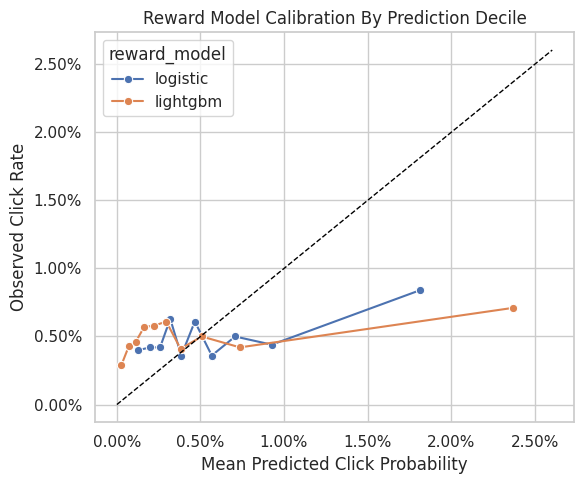

,prediction_bin,mean_prediction,observed_click_rate,rows,reward_model
0,0,0.001292,0.004000,10000,logistic
1,1,0.001987,0.004200,10000,logistic
2,2,0.002585,0.004200,10000,logistic
3,3,0.003192,0.006300,10000,logistic
4,4,0.003855,0.003600,10000,logistic
5,5,0.004663,0.006100,10000,logistic
6,6,0.005678,0.003600,10000,logistic
7,7,0.007076,0.005000,10000,logistic
8,8,0.009268,0.004400,10000,logistic
9,9,0.018137,0.008400,10000,logistic


In [11]:
# Plot reward model calibration.
calibration_frames = []
for model_name, pred in logged_predictions.items():
    calibration_frame = pd.DataFrame({"prediction": pred, "click": y_eval.to_numpy()})
    calibration_frame["prediction_bin"] = pd.qcut(
        calibration_frame["prediction"].rank(method="first"), q=10, labels=False
    )
    calibration_summary = (
        calibration_frame.groupby("prediction_bin")
        .agg(mean_prediction=("prediction", "mean"), observed_click_rate=("click", "mean"), rows=("click", "size"))
        .reset_index()
    )
    calibration_summary["reward_model"] = model_name
    calibration_frames.append(calibration_summary)

calibration_df = pd.concat(calibration_frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.lineplot(
    data=calibration_df,
    x="mean_prediction",
    y="observed_click_rate",
    hue="reward_model",
    marker="o",
    ax=ax,
)
max_axis = max(calibration_df["mean_prediction"].max(), calibration_df["observed_click_rate"].max()) * 1.1
ax.plot([0, max_axis], [0, max_axis], color="black", linestyle="--", linewidth=1)
ax.set_title("Reward Model Calibration By Prediction Decile")
ax.set_xlabel("Mean Predicted Click Probability")
ax.set_ylabel("Observed Click Rate")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
plt.tight_layout()
plt.show()

calibration_df


The reward-model diagnostics show whether predicted click probabilities align with observed clicks. Calibration matters because DR uses these predictions as counterfactual baselines before applying residual correction. When predicted risks and observed frequencies diverge, residual corrections and policy values become harder to interpret.


### Recreate Evaluation Policies

This cell rebuilds the same four evaluation policies used in Notebook 3:

- `uniform`
- `exposure_popularity`
- `ctr_weighted`
- `epsilon_greedy_top_ctr`

Keeping the policies identical allows us to compare IPS, SNIPS, direct method, and DR estimates without changing the target estimand.


In [12]:
# Recreate evaluation policies from notebook 3.
SMOOTHING_ALPHA = 50
train_global_ctr = train_df["click"].mean()

item_stats = (
    train_df.groupby("item_id")
    .agg(train_impressions=("click", "size"), train_clicks=("click", "sum"), train_ctr=("click", "mean"))
    .reindex(action_space, fill_value=0)
    .rename_axis("item_id")
    .reset_index()
)
item_stats["smoothed_ctr"] = (
    item_stats["train_clicks"] + SMOOTHING_ALPHA * train_global_ctr
) / (item_stats["train_impressions"] + SMOOTHING_ALPHA)
item_stats["train_exposure_share"] = item_stats["train_impressions"] / item_stats["train_impressions"].sum()


def normalize_probabilities(values):
    """
    Normalize nonnegative scores into action probabilities.
    
    Idea
    ----
    The helper turns item scores into a valid evaluation-policy distribution and protects OPE estimators from zero-sum or invalid probability vectors.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    
    Returns
    -------
    numpy.ndarray
        Probability vector that sums to one.
    """
    values = np.asarray(values, dtype=float)
    values = np.clip(values, 0, None)
    total = values.sum()
    if total <= 0:
        raise ValueError("Policy scores must have positive total mass.")
    return values / total

uniform_probs = np.full(n_actions, 1 / n_actions)
exposure_popularity_probs = normalize_probabilities(item_stats["train_exposure_share"].to_numpy())
ctr_weighted_probs = normalize_probabilities(item_stats["smoothed_ctr"].to_numpy())

epsilon = 0.15
epsilon_greedy_probs = np.full(n_actions, epsilon / n_actions)
top_ctr_index = int(item_stats["smoothed_ctr"].to_numpy().argmax())
epsilon_greedy_probs[top_ctr_index] += 1 - epsilon

policy_cols = ["uniform", "exposure_popularity", "ctr_weighted", "epsilon_greedy_top_ctr"]
policy_probability_df = pd.DataFrame(
    {
        "item_id": action_space,
        "uniform": uniform_probs,
        "exposure_popularity": exposure_popularity_probs,
        "ctr_weighted": ctr_weighted_probs,
        "epsilon_greedy_top_ctr": epsilon_greedy_probs,
    }
)

policy_probability_df.head()


,item_id,uniform,exposure_popularity,ctr_weighted,epsilon_greedy_top_ctr
0,0,0.029412,0.029200,0.040498,0.004412
1,1,0.029412,0.027590,0.025514,0.004412
2,2,0.029412,0.032070,0.036929,0.004412
3,3,0.029412,0.029650,0.020188,0.004412
4,4,0.029412,0.028410,0.017318,0.004412


This output is part of the doubly robust off-policy evaluation workflow. Read it as a checkpoint that either verifies the log, defines reusable estimator machinery, or produces a diagnostic that motivates the next OPE step.


#### Audit Evaluation Policy Probabilities

Before using policy probabilities in an estimator, we check that each policy is valid.

A policy must assign probabilities that sum to 1 and must assign nonnegative probabilities. In this notebook, every candidate policy also gives every action positive probability, which keeps support diagnostics straightforward.


In [13]:
policy_audit = pd.DataFrame(
    [
        {
            "policy": policy,
            "probability_sum": policy_probability_df[policy].sum(),
            "min_probability": policy_probability_df[policy].min(),
            "max_probability": policy_probability_df[policy].max(),
            "positive_actions": int((policy_probability_df[policy] > 0).sum()),
        }
        for policy in policy_cols
    ]
)

policy_audit


,policy,probability_sum,min_probability,max_probability,positive_actions
0,uniform,1.000000,0.029412,0.029412,34
1,exposure_popularity,1.000000,0.025810,0.033300,34
2,ctr_weighted,1.000000,0.009558,0.080613,34
3,epsilon_greedy_top_ctr,1.000000,0.004412,0.854412,34


This output is part of the doubly robust off-policy evaluation workflow. Read it as a checkpoint that either verifies the log, defines reusable estimator machinery, or produces a diagnostic that motivates the next OPE step.


#### Create Candidate-Action Feature Frames

The direct method and DR estimator need reward predictions for every candidate action in every evaluation context.

This helper builds a feature frame for all `(context, candidate item)` pairs in a batch. For each context row, it repeats the context features once per action, attaches candidate item metadata, and selects the affinity score for that candidate item.

Batching keeps memory usage reasonable. The full evaluation split has 100,000 contexts and 34 actions, so scoring everything at once would create 3.4 million rows.


In [14]:
# Create candidate-action feature frames.
def make_candidate_feature_frame(context_df):
    """
    Create reward-model features for every candidate action in each context.
    
    Idea
    ----
    This expands each context across the action space so direct-method and contextual-policy predictions can evaluate actions that were not logged on that row.
    
    Parameters
    ----------
    context_df : object
        Context rows for which candidate actions are evaluated.
    
    Returns
    -------
    pandas.DataFrame
        Long feature frame containing one row per context-action pair.
    """
    n_contexts = len(context_df)
    tiled_actions = np.tile(action_space, n_contexts)

    frame = pd.DataFrame(
        {
            "position": np.repeat(context_df["position"].to_numpy(), n_actions),
            "hour": np.repeat(context_df["hour"].to_numpy(), n_actions),
            "item_id": tiled_actions,
        }
    )

    for col in user_feature_cols:
        frame[col] = np.repeat(context_df[col].to_numpy(), n_actions)

    affinity_matrix = context_df[affinity_cols_by_action].to_numpy()
    frame["selected_affinity"] = affinity_matrix.reshape(-1)

    repeated_item_context = item_context.loc[tiled_actions, item_feature_cols].reset_index(drop=True)
    frame = pd.concat([frame, repeated_item_context], axis=1)

    return frame[feature_cols]

candidate_preview = make_candidate_feature_frame(eval_df.head(2))
candidate_preview


,position,hour,item_id,user_feature_0,user_feature_1,user_feature_2,user_feature_3,item_feature_1,item_feature_2,item_feature_3,selected_affinity,item_feature_0
0,2,10,0,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,ce58bf66d7e62186e6ce01bafeea9d39,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c,0.000000,-0.677183
1,2,10,1,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,3c2985d744e0d57c261abd7e541e4263,7c5498711d69681385d21c0e26923e7e,bbf748c6c978938bc63d432efa60191c,0.000000,-0.720300
2,2,10,2,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,3c2985d744e0d57c261abd7e541e4263,2b851c0a9c4a961da8760d5dc747c5a3,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,0.745662
3,2,10,3,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,9874ffb54e9b0a269e29bbb2f5328735,ce1abd8b5d914ba8fe719b453bc5ba3b,5bc9c86cd1f08a9991670ea97b34f86d,0.000000,-0.698741
4,2,10,4,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,01fe2f187e459e6ada960671d2942dfe,b4b5879029fb5f64eeec63cf4f73ef0e,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,1.651109
5,2,10,5,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,01fe2f187e459e6ada960671d2942dfe,c43671ed6855a6fe2e2a6030cba64366,bbf748c6c978938bc63d432efa60191c,0.000000,0.142031
6,2,10,6,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,ce58bf66d7e62186e6ce01bafeea9d39,7082af732502f0981a9fe77d7ba1ae8a,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,1.651109
7,2,10,7,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,01fe2f187e459e6ada960671d2942dfe,2b851c0a9c4a961da8760d5dc747c5a3,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,2.858372
8,2,10,8,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,01fe2f187e459e6ada960671d2942dfe,d7f03898d040700d6e1810d21e669958,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,1.349294
9,2,10,9,cef3390ed299c09874189c387777674a,2d03db5543b14483e52d761760686b64,2723d2eb8bba04e0362098011fa3997b,9bde591ffaab8d54c457448e4dca6f53,9874ffb54e9b0a269e29bbb2f5328735,2b851c0a9c4a961da8760d5dc747c5a3,b61cfaadd526b816e3aeb9b7be4b4759,0.000000,1.198386


These feature-building cells define the context used by reward models. Reward models need both user context and candidate item context so they can predict counterfactual rewards for unlogged actions.


#### Compute Direct-Method Components In Batches

This helper scores every evaluation context against every candidate item for one reward model.

For each context, it computes:

`sum_a pi_e(a|x) * q_hat(x, a)`

Because our evaluation policies are context-free, the policy probabilities are constant by row. The reward predictions still vary by row because user features, position, hour, and selected affinity vary by context.


In [15]:
# Compute direct-method components in batches.
def compute_direct_components(model, contexts_df, batch_size=10_000):
    """
    Compute direct-method value components for candidate policies.
    
    Idea
    ----
    The function predicts rewards for every context-action pair, weights those predictions by policy probabilities, and returns one model-based value component per context.
    
    Parameters
    ----------
    model : object
        Fitted or unfitted model used in the helper.
    contexts_df : object
        Context rows for which candidate actions are evaluated.
    batch_size : object
        Number of rows to score in each prediction batch.
    
    Returns
    -------
    pandas.DataFrame
        Direct-method components aligned with evaluation contexts and policies.
    """
    policy_probability_matrix = policy_probability_df[policy_cols].to_numpy()
    component_batches = []

    for start in range(0, len(contexts_df), batch_size):
        context_batch = contexts_df.iloc[start : start + batch_size]
        candidate_features = make_candidate_feature_frame(context_batch)
        q_hat = model.predict_proba(candidate_features)[:, 1].reshape(len(context_batch), n_actions)
        direct_components = q_hat @ policy_probability_matrix
        component_batches.append(direct_components)

    components = np.vstack(component_batches)
    return pd.DataFrame(components, columns=policy_cols, index=contexts_df.index)


These cells score candidate actions under the reward model, which is what lets the direct method estimate values for policies that choose actions different from the logged one. This is the model-based complement to importance weighting.


#### Score Logged Actions And Candidate Actions

This cell produces the two reward-model prediction objects needed for DR:

- `q_hat_logged`: predicted click probability for the item that was actually logged
- `direct_components`: expected predicted reward under each evaluation policy for each context

The direct components are the model-based policy values before residual correction.


In [16]:
q_logged_by_model = {}
direct_components_by_model = {}

for model_name, model in reward_models.items():
    q_logged_by_model[model_name] = model.predict_proba(X_eval_logged)[:, 1]
    direct_components_by_model[model_name] = compute_direct_components(model, eval_df, batch_size=10_000)

pd.DataFrame(
    {
        "reward_model": list(q_logged_by_model),
        "mean_q_logged": [pred.mean() for pred in q_logged_by_model.values()],
        "direct_component_rows": [len(direct_components_by_model[name]) for name in q_logged_by_model],
    }
)


,reward_model,mean_q_logged,direct_component_rows
0,logistic,0.005774,100000
1,lightgbm,0.004888,100000


These cells score candidate actions under the reward model, which is what lets the direct method estimate values for policies that choose actions different from the logged one. This is the model-based complement to importance weighting.


#### Attach Evaluation Policy Weights

This cell computes `pi_e(A|X) / pi_b(A|X)` for the logged action under each evaluation policy.

These are the same importance weights used in Notebook 3. In the doubly robust estimator, the weights multiply the reward-model residual `Y - q_hat(X, A)`.


In [17]:
eval_scored = eval_df[["timestamp", "item_id", "position", "click", "propensity_score"]].copy()

for policy in policy_cols:
    probability_map = policy_probability_df.set_index("item_id")[policy]
    eval_scored[f"pi_e_{policy}"] = eval_scored["item_id"].map(probability_map)
    eval_scored[f"w_{policy}"] = eval_scored[f"pi_e_{policy}"] / eval_scored["propensity_score"]

weight_check = pd.DataFrame(
    [
        {
            "policy": policy,
            "mean_weight": eval_scored[f"w_{policy}"].mean(),
            "max_weight": eval_scored[f"w_{policy}"].max(),
            "p99_weight": np.percentile(eval_scored[f"w_{policy}"], 99),
        }
        for policy in policy_cols
    ]
)

weight_check


,policy,mean_weight,max_weight,p99_weight
0,uniform,1.000000,1.000000,1.000000
1,exposure_popularity,1.000591,1.132200,1.132200
2,ctr_weighted,0.996987,2.740842,2.740842
3,epsilon_greedy_top_ctr,1.001105,29.050000,29.050000


Attaching evaluation-policy probabilities to logged rows creates the numerator of the importance weight. Once this is joined to the behavior propensity, IPS and SNIPS can estimate each policy's value.


### Define OPE Estimators

This cell defines helper functions for IPS, SNIPS, direct method, and doubly robust estimation.

Each estimator returns an estimate, approximate standard error, confidence interval, and weight diagnostics where relevant. The confidence intervals use large-sample standard errors. They are useful for comparison, but later production work would likely use richer bootstrap or repeated-split diagnostics.


In [18]:
# Define OPE estimator helpers.
def effective_sample_size(weights):
    """
    Compute the effective sample size implied by importance weights.
    
    Idea
    ----
    Large or unstable weights can make an estimator behave as if it had far fewer observations; this diagnostic turns weight concentration into a readable sample-size number.
    
    Parameters
    ----------
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Effective sample size computed as squared total weight divided by total squared weight.
    """
    weights = np.asarray(weights, dtype=float)
    return weights.sum() ** 2 / np.square(weights).sum()


def summarize_signal(signal):
    """
    Summarize the distribution of an OPE diagnostic signal.
    
    Idea
    ----
    The helper reports quantiles and extremes for weights, propensities, or residual terms so unstable policies are easy to spot.
    
    Parameters
    ----------
    signal : object
        Diagnostic vector to summarize.
    
    Returns
    -------
    dict
        Summary statistics for the supplied diagnostic vector.
    """
    signal = np.asarray(signal, dtype=float)
    estimate = signal.mean()
    se = signal.std(ddof=1) / np.sqrt(len(signal))
    return estimate, se, estimate - 1.96 * se, estimate + 1.96 * se


def estimate_ips_snips(reward, weight):
    """
    Estimate IPS and self-normalized IPS policy values.
    
    Idea
    ----
    The helper applies importance weights to logged rewards, optionally with clipping, so fixed or contextual policies can be compared under support diagnostics.
    
    Parameters
    ----------
    reward : object
        Observed logged reward values.
    weight : object
        Importance weights for the evaluation policy.
    
    Returns
    -------
    dict
        IPS and SNIPS estimates with the clipping rule used.
    """
    reward = np.asarray(reward, dtype=float)
    weight = np.asarray(weight, dtype=float)
    ips_signal = weight * reward
    ips, ips_se, ips_lower, ips_upper = summarize_signal(ips_signal)

    snips = ips_signal.sum() / weight.sum()
    snips_influence = weight * (reward - snips) / weight.mean()
    snips_se = snips_influence.std(ddof=1) / np.sqrt(len(snips_influence))

    return {
        "ips": (ips, ips_se, ips_lower, ips_upper),
        "snips": (snips, snips_se, snips - 1.96 * snips_se, snips + 1.96 * snips_se),
        "ess_share": effective_sample_size(weight) / len(weight),
        "mean_weight": weight.mean(),
        "max_weight": weight.max(),
    }


def estimate_dm_dr(reward, weight, q_logged, direct_component):
    """
    Estimate direct-method and doubly robust policy values.
    
    Idea
    ----
    The function combines reward-model predictions with inverse-propensity correction so model-based and doubly robust estimates can be compared.
    
    Parameters
    ----------
    reward : object
        Observed logged reward values.
    weight : object
        Importance weights for the evaluation policy.
    q_logged : object
        Reward-model prediction for the logged action.
    direct_component : object
        Direct-method value component for the evaluation policy.
    
    Returns
    -------
    dict
        Direct-method and doubly robust value estimates.
    """
    reward = np.asarray(reward, dtype=float)
    weight = np.asarray(weight, dtype=float)
    q_logged = np.asarray(q_logged, dtype=float)
    direct_component = np.asarray(direct_component, dtype=float)

    dm, dm_se, dm_lower, dm_upper = summarize_signal(direct_component)
    dr_signal = direct_component + weight * (reward - q_logged)
    dr, dr_se, dr_lower, dr_upper = summarize_signal(dr_signal)

    correction = dr_signal - direct_component
    return {
        "dm": (dm, dm_se, dm_lower, dm_upper),
        "dr": (dr, dr_se, dr_lower, dr_upper),
        "mean_abs_correction": np.abs(correction).mean(),
        "mean_correction": correction.mean(),
    }


The helper functions encode the estimator formulas and diagnostics used repeatedly in the notebook. Defining them once keeps the later policy comparisons consistent and easier to audit.


#### Estimate IPS, SNIPS, Direct Method, And DR

This cell computes the main OPE result table.

For each policy, IPS and SNIPS depend only on propensities and observed rewards. Direct method and DR are computed separately for each reward model. The DR estimate uses the reward model prediction plus an importance-weighted residual correction.


In [19]:
# Estimate IPS, SNIPS, direct method, and DR.
result_rows = []
reward = eval_scored["click"].to_numpy()

for policy in policy_cols:
    weight = eval_scored[f"w_{policy}"].to_numpy()
    ips_snips = estimate_ips_snips(reward, weight)

    for estimator_name, values in [("IPS", ips_snips["ips"]), ("SNIPS", ips_snips["snips"] )]:
        estimate, se, lower, upper = values
        result_rows.append(
            {
                "policy": policy,
                "estimator": estimator_name,
                "reward_model": "none",
                "estimate": estimate,
                "se": se,
                "ci_95_lower": lower,
                "ci_95_upper": upper,
                "ess_share": ips_snips["ess_share"],
                "mean_weight": ips_snips["mean_weight"],
                "max_weight": ips_snips["max_weight"],
                "mean_abs_correction": np.nan,
                "mean_correction": np.nan,
            }
        )

    for model_name in reward_models:
        dm_dr = estimate_dm_dr(
            reward=reward,
            weight=weight,
            q_logged=q_logged_by_model[model_name],
            direct_component=direct_components_by_model[model_name][policy],
        )
        for estimator_name, values in [("DM", dm_dr["dm"]), ("DR", dm_dr["dr"] )]:
            estimate, se, lower, upper = values
            result_rows.append(
                {
                    "policy": policy,
                    "estimator": estimator_name,
                    "reward_model": model_name,
                    "estimate": estimate,
                    "se": se,
                    "ci_95_lower": lower,
                    "ci_95_upper": upper,
                    "ess_share": ips_snips["ess_share"],
                    "mean_weight": ips_snips["mean_weight"],
                    "max_weight": ips_snips["max_weight"],
                    "mean_abs_correction": dm_dr["mean_abs_correction"],
                    "mean_correction": dm_dr["mean_correction"],
                }
            )

all_estimates = pd.DataFrame(result_rows)
all_estimates.head(12)


,policy,estimator,reward_model,estimate,se,ci_95_lower,ci_95_upper,ess_share,mean_weight,max_weight,mean_abs_correction,mean_correction
0,uniform,IPS,none,0.004980,0.000223,0.004544,0.005416,1.000000,1.000000,1.000000,NaN,NaN
1,uniform,SNIPS,none,0.004980,0.000223,0.004544,0.005416,1.000000,1.000000,1.000000,NaN,NaN
2,uniform,DM,logistic,0.005786,0.000011,0.005764,0.005807,1.000000,1.000000,1.000000,0.010685,-0.000794
3,uniform,DR,logistic,0.004992,0.000225,0.004550,0.005434,1.000000,1.000000,1.000000,0.010685,-0.000794
4,uniform,DM,lightgbm,0.004943,0.000013,0.004918,0.004968,1.000000,1.000000,1.000000,0.009813,0.000092
5,uniform,DR,lightgbm,0.005035,0.000226,0.004592,0.005477,1.000000,1.000000,1.000000,0.009813,0.000092
6,exposure_popularity,IPS,none,0.004971,0.000223,0.004535,0.005407,0.996399,1.000591,1.132200,NaN,NaN
7,exposure_popularity,SNIPS,none,0.004968,0.000223,0.004532,0.005404,0.996399,1.000591,1.132200,NaN,NaN
8,exposure_popularity,DM,logistic,0.005733,0.000011,0.005711,0.005754,0.996399,1.000591,1.132200,0.010630,-0.000756
9,exposure_popularity,DR,logistic,0.004977,0.000225,0.004535,0.005418,0.996399,1.000591,1.132200,0.010630,-0.000756


This table compares the main OPE estimator families. DR is especially useful because it combines reward-model predictions with importance-weighted residuals, reducing reliance on either component alone.


#### Add The Observed Random-Policy Baseline

The held-out observed click rate is the on-policy value estimate for the random behavior policy. It gives the table a concrete baseline.

Policy lift in later cells is measured relative to this observed random-policy click rate.


In [20]:
behavior_value = eval_scored["click"].mean()
behavior_se = eval_scored["click"].std(ddof=1) / np.sqrt(len(eval_scored))

observed_baseline = pd.DataFrame(
    [
        {
            "policy": "behavior_random_observed",
            "estimator": "Observed",
            "reward_model": "none",
            "estimate": behavior_value,
            "se": behavior_se,
            "ci_95_lower": behavior_value - 1.96 * behavior_se,
            "ci_95_upper": behavior_value + 1.96 * behavior_se,
            "ess_share": 1.0,
            "mean_weight": 1.0,
            "max_weight": 1.0,
            "mean_abs_correction": np.nan,
            "mean_correction": np.nan,
        }
    ]
)

estimate_table = pd.concat([observed_baseline, all_estimates], ignore_index=True)
estimate_table["lift_pp"] = 100 * (estimate_table["estimate"] - behavior_value)
estimate_table["relative_lift_pct"] = 100 * (estimate_table["estimate"] / behavior_value - 1)

estimate_table.sort_values(["policy", "estimator", "reward_model"]).head(20)


,policy,estimator,reward_model,estimate,se,ci_95_lower,ci_95_upper,ess_share,mean_weight,max_weight,mean_abs_correction,mean_correction,lift_pp,relative_lift_pct
0,behavior_random_observed,Observed,none,0.004980,0.000223,0.004544,0.005416,1.000000,1.000000,1.000000,NaN,NaN,0.000000,0.000000
17,ctr_weighted,DM,lightgbm,0.006021,0.000016,0.005989,0.006052,0.790628,0.996987,2.740842,0.011017,-0.000741,0.104055,20.894635
15,ctr_weighted,DM,logistic,0.007355,0.000014,0.007328,0.007382,0.790628,0.996987,2.740842,0.012451,-0.002195,0.237523,47.695402
18,ctr_weighted,DR,lightgbm,0.005280,0.000267,0.004756,0.005803,0.790628,0.996987,2.740842,0.011017,-0.000741,0.029956,6.015257
16,ctr_weighted,DR,logistic,0.005160,0.000268,0.004634,0.005687,0.790628,0.996987,2.740842,0.012451,-0.002195,0.018048,3.624090
13,ctr_weighted,IPS,none,0.005172,0.000261,0.004660,0.005685,0.790628,0.996987,2.740842,NaN,NaN,0.019244,3.864167
14,ctr_weighted,SNIPS,none,0.005188,0.000262,0.004675,0.005701,0.790628,0.996987,2.740842,NaN,NaN,0.020806,4.178004
23,epsilon_greedy_top_ctr,DM,lightgbm,0.011740,0.000068,0.011607,0.011873,0.040290,1.001105,29.050000,0.017472,-0.005122,0.676002,135.743313
21,epsilon_greedy_top_ctr,DM,logistic,0.014628,0.000025,0.014580,0.014676,0.040290,1.001105,29.050000,0.020619,-0.008321,0.964777,193.730292
24,epsilon_greedy_top_ctr,DR,lightgbm,0.006618,0.001324,0.004023,0.009214,0.040290,1.001105,29.050000,0.017472,-0.005122,0.163824,32.896440


Adding the observed behavior-policy baseline gives a familiar reference point. Evaluation policies can now be interpreted as offline alternatives to the policy that generated the held-out log.


### Compare Main Estimators Visually

This plot compares IPS, SNIPS, and LightGBM DR estimates. LightGBM DR is shown because it is the strongest reward model in this notebook, while IPS and SNIPS provide continuity with Notebook 3.

The confidence intervals are approximate. The main purpose of the plot is to show whether DR stabilizes policy rankings and whether it agrees directionally with pure importance weighting.


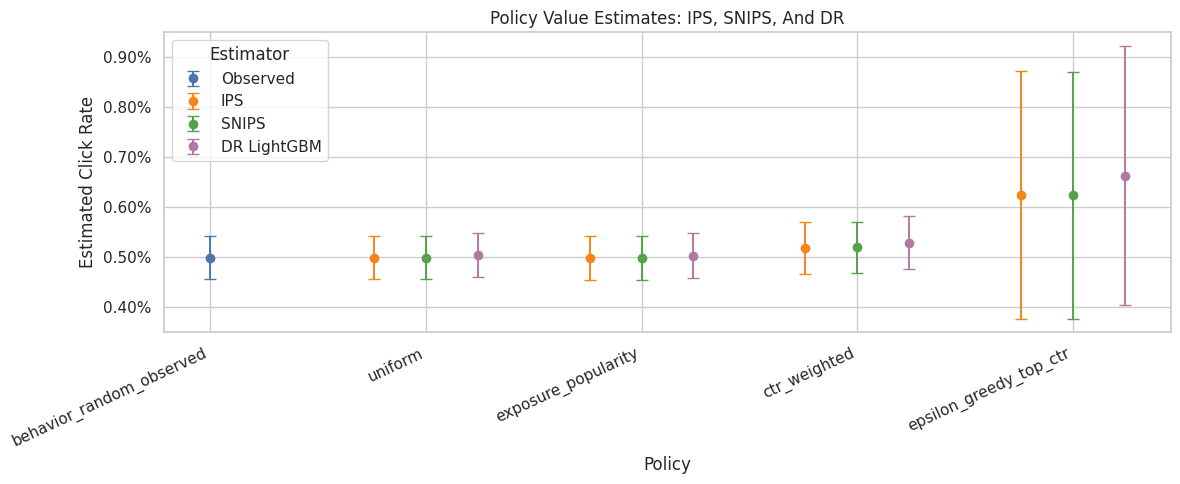

In [21]:
# Compare main estimators visually.
plot_estimates = estimate_table[
    (estimate_table["estimator"].isin(["Observed", "IPS", "SNIPS"]))
    | ((estimate_table["estimator"] == "DR") & (estimate_table["reward_model"] == "lightgbm"))
].copy()
plot_estimates["estimator_label"] = np.where(
    plot_estimates["estimator"] == "DR",
    "DR LightGBM",
    plot_estimates["estimator"],
)
plot_estimates["lower_error"] = plot_estimates["estimate"] - plot_estimates["ci_95_lower"]
plot_estimates["upper_error"] = plot_estimates["ci_95_upper"] - plot_estimates["estimate"]

policy_order = plot_estimates["policy"].drop_duplicates().tolist()
estimator_order = ["Observed", "IPS", "SNIPS", "DR LightGBM"]
offsets = {"Observed": 0.0, "IPS": -0.24, "SNIPS": 0.0, "DR LightGBM": 0.24}
colors = {"Observed": "#4C78A8", "IPS": "#F58518", "SNIPS": "#54A24B", "DR LightGBM": "#B279A2"}

fig, ax = plt.subplots(figsize=(12, 5))
for estimator in estimator_order:
    subset = plot_estimates[plot_estimates["estimator_label"] == estimator]
    for _, row in subset.iterrows():
        x_base = policy_order.index(row["policy"])
        x = x_base + offsets[estimator]
        ax.errorbar(
            x=x,
            y=row["estimate"],
            yerr=[[row["lower_error"]], [row["upper_error"]]],
            fmt="o",
            color=colors[estimator],
            ecolor=colors[estimator],
            capsize=4,
            linewidth=1.4,
            markersize=6,
            label=estimator if row["policy"] == subset["policy"].iloc[0] else None,
        )

ax.set_xticks(range(len(policy_order)))
ax.set_xticklabels(policy_order, rotation=25, ha="right")
ax.set_title("Policy Value Estimates: IPS, SNIPS, And DR")
ax.set_xlabel("Policy")
ax.set_ylabel("Estimated Click Rate")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
ax.legend(title="Estimator")
plt.tight_layout()
plt.show()


This output is part of the doubly robust off-policy evaluation workflow. Read it as a checkpoint that either verifies the log, defines reusable estimator machinery, or produces a diagnostic that motivates the next OPE step.


#### Direct Method Versus DR By Reward Model

This table compares direct method and DR estimates for both reward models.

The direct method is fully model-based. DR adds the residual correction. If the correction is large, observed outcomes disagree with the reward model in a way that matters for that policy. Large corrections deserve interpretation.


In [22]:
dm_dr_table = estimate_table[estimate_table["estimator"].isin(["DM", "DR"])].copy()
dm_dr_table = dm_dr_table[
    [
        "policy",
        "reward_model",
        "estimator",
        "estimate",
        "ci_95_lower",
        "ci_95_upper",
        "lift_pp",
        "relative_lift_pct",
        "mean_abs_correction",
        "mean_correction",
    ]
].sort_values(["policy", "reward_model", "estimator"])

dm_dr_table


,policy,reward_model,estimator,estimate,ci_95_lower,ci_95_upper,lift_pp,relative_lift_pct,mean_abs_correction,mean_correction
17,ctr_weighted,lightgbm,DM,0.006021,0.005989,0.006052,0.104055,20.894635,0.011017,-0.000741
18,ctr_weighted,lightgbm,DR,0.005280,0.004756,0.005803,0.029956,6.015257,0.011017,-0.000741
15,ctr_weighted,logistic,DM,0.007355,0.007328,0.007382,0.237523,47.695402,0.012451,-0.002195
16,ctr_weighted,logistic,DR,0.005160,0.004634,0.005687,0.018048,3.624090,0.012451,-0.002195
23,epsilon_greedy_top_ctr,lightgbm,DM,0.011740,0.011607,0.011873,0.676002,135.743313,0.017472,-0.005122
24,epsilon_greedy_top_ctr,lightgbm,DR,0.006618,0.004023,0.009214,0.163824,32.896440,0.017472,-0.005122
21,epsilon_greedy_top_ctr,logistic,DM,0.014628,0.014580,0.014676,0.964777,193.730292,0.020619,-0.008321
22,epsilon_greedy_top_ctr,logistic,DR,0.006306,0.003799,0.008814,0.132637,26.633840,0.020619,-0.008321
11,exposure_popularity,lightgbm,DM,0.004913,0.004888,0.004938,-0.006709,-1.347183,0.009779,0.000108
12,exposure_popularity,lightgbm,DR,0.005021,0.004578,0.005463,0.004067,0.816622,0.009779,0.000108


Comparing DM and DR shows how much the residual correction changes the model-only estimate. Large differences mean observed logged rewards are correcting the reward model substantially. The important comparison is which policy remains credible after support, uncertainty, and operational constraints are considered.


#### Plot Direct Method Versus DR

This plot focuses only on model-based estimators. It shows how much the DR correction moves the direct-method estimates for each reward model.

The labels combine estimator and reward model, for example `DR lightgbm`. This avoids overloading Seaborn with multiple grouping variables and makes the comparison easier to read.


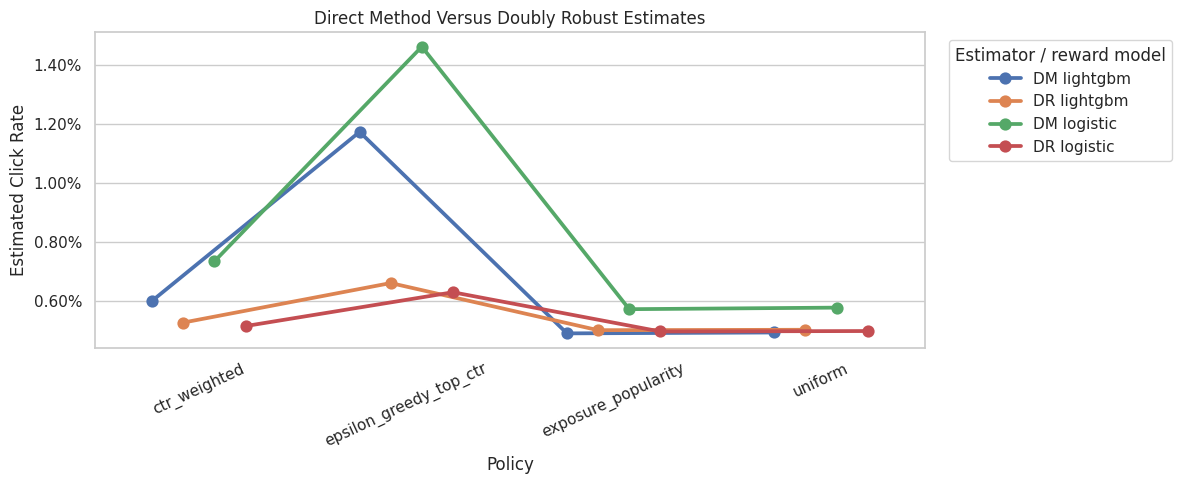

In [23]:
dm_dr_plot = dm_dr_table.copy()
dm_dr_plot["estimator_model"] = dm_dr_plot["estimator"] + " " + dm_dr_plot["reward_model"]

fig, ax = plt.subplots(figsize=(12, 5))
sns.pointplot(
    data=dm_dr_plot,
    x="policy",
    y="estimate",
    hue="estimator_model",
    dodge=0.45,
    errorbar=None,
    ax=ax,
)
ax.set_title("Direct Method Versus Doubly Robust Estimates")
ax.set_xlabel("Policy")
ax.set_ylabel("Estimated Click Rate")
ax.tick_params(axis="x", rotation=25)
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
ax.legend(title="Estimator / reward model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Comparing DM and DR shows how much the residual correction changes the model-only estimate. Large differences mean observed logged rewards are correcting the reward model substantially. The result should be read together with support diagnostics because a good reward model cannot fully rescue evaluation when the logging policy rarely explored the relevant actions.


### DR Correction Diagnostics

This cell summarizes the size of the residual correction in the DR estimator. The correction term is:

`weight * (Y - q_hat(X, A))`

A correction near zero on average means the direct method already aligns with observed residuals under that policy. A larger correction means the logged outcomes are materially changing the model-based estimate.


In [24]:
correction_diagnostics = (
    estimate_table.query("estimator == 'DR'")
    [["policy", "reward_model", "mean_correction", "mean_abs_correction", "ess_share", "max_weight"]]
    .sort_values("mean_abs_correction", ascending=False)
)

correction_diagnostics


,policy,reward_model,mean_correction,mean_abs_correction,ess_share,max_weight
22,epsilon_greedy_top_ctr,logistic,-0.008321,0.020619,0.040290,29.050000
24,epsilon_greedy_top_ctr,lightgbm,-0.005122,0.017472,0.040290,29.050000
16,ctr_weighted,logistic,-0.002195,0.012451,0.790628,2.740842
18,ctr_weighted,lightgbm,-0.000741,0.011017,0.790628,2.740842
4,uniform,logistic,-0.000794,0.010685,1.000000,1.000000
10,exposure_popularity,logistic,-0.000756,0.010630,0.996399,1.132200
6,uniform,lightgbm,0.000092,0.009813,1.000000,1.000000
12,exposure_popularity,lightgbm,0.000108,0.009779,0.996399,1.132200


The correction diagnostics reveal how much of the DR estimate comes from importance-weighted residuals. Large or unstable corrections point to either support issues, reward-model misspecification, or both.


### LightGBM Feature Importance

This cell extracts the top LightGBM feature importances after preprocessing.

Feature importance is a model-debugging tool. It tells us which transformed features the reward model used for prediction. A sensible model should use item identity, position, user features, item metadata, or affinity signals, with little weight on random artifacts.


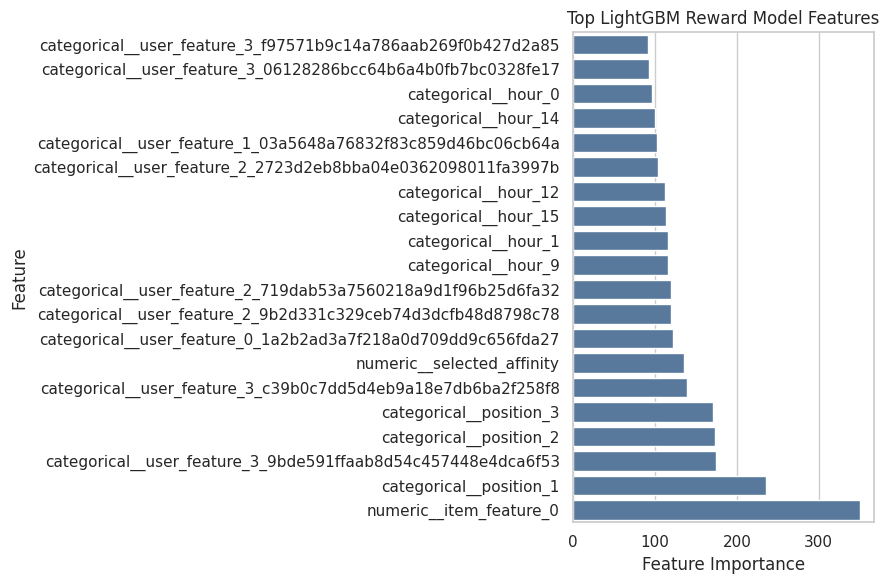

,feature,importance
119,numeric__item_feature_0,350
0,categorical__position_1,236
87,categorical__user_feature_3_9bde591ffaab8d54c4...,174
1,categorical__position_2,173
2,categorical__position_3,171
88,categorical__user_feature_3_c39b0c7dd5d4eb9a18...,139
118,numeric__selected_affinity,136
61,categorical__user_feature_0_1a2b2ad3a7f218a0d7...,122
77,categorical__user_feature_2_9b2d331c329ceb74d3...,120
74,categorical__user_feature_2_719dab53a7560218a9...,119


In [25]:
lightgbm_pipeline = reward_models["lightgbm"]
feature_names = lightgbm_pipeline.named_steps["preprocess"].get_feature_names_out()
feature_importances = lightgbm_pipeline.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": feature_importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=importance_df.sort_values("importance"), x="importance", y="feature", ax=ax, color="#4C78A8")
ax.set_title("Top LightGBM Reward Model Features")
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

importance_df


Feature importance helps explain what the reward model uses to predict clicks. These importances support model interpretation, while causal interpretation remains tied to the policy estimand and assumptions.


### Weight and Model Diagnostics Together

This cell brings together the two main sources of uncertainty:

- importance-weight stability
- reward-model quality

A good DR estimate should have reasonable support and a reward model that is at least directionally predictive. Weak weights plus a weak reward model would make any offline policy conclusion fragile.


In [26]:
lightgbm_metric_row = reward_model_metrics.query("reward_model == 'lightgbm'").iloc[0]
combined_diagnostics = (
    estimate_table.query("estimator == 'DR' and reward_model == 'lightgbm'")
    [["policy", "estimate", "lift_pp", "ess_share", "mean_weight", "max_weight", "mean_abs_correction"]]
    .assign(
        reward_model_auc=lightgbm_metric_row["auc"],
        reward_model_log_loss=lightgbm_metric_row["log_loss"],
        reward_model_brier=lightgbm_metric_row["brier_score"],
    )
    .sort_values("estimate", ascending=False)
)

combined_diagnostics


,policy,estimate,lift_pp,ess_share,mean_weight,max_weight,mean_abs_correction,reward_model_auc,reward_model_log_loss,reward_model_brier
24,epsilon_greedy_top_ctr,0.006618,0.163824,0.040290,1.001105,29.050000,0.017472,0.533007,0.034352,0.005104
18,ctr_weighted,0.005280,0.029956,0.790628,0.996987,2.740842,0.011017,0.533007,0.034352,0.005104
6,uniform,0.005035,0.005491,1.000000,1.000000,1.000000,0.009813,0.533007,0.034352,0.005104
12,exposure_popularity,0.005021,0.004067,0.996399,1.000591,1.132200,0.009779,0.533007,0.034352,0.005104


Combining weight and model diagnostics gives a fuller risk picture than policy value alone. A policy should look good on estimated reward, support, ESS, and model quality.


### Main Result Table

This final result table is the compact version to reference in a project report.

It focuses on LightGBM DR because that is the strongest reward-model version in this notebook, while still retaining IPS and SNIPS as benchmarks from the previous notebook. The best policy should be interpreted alongside ESS, confidence intervals, and the observational limitations of logged bandit data.


In [27]:
main_result_table = estimate_table[
    (estimate_table["estimator"].isin(["Observed", "IPS", "SNIPS"]))
    | ((estimate_table["estimator"] == "DR") & (estimate_table["reward_model"] == "lightgbm"))
].copy()
main_result_table = main_result_table[
    [
        "policy",
        "estimator",
        "reward_model",
        "estimate",
        "ci_95_lower",
        "ci_95_upper",
        "lift_pp",
        "relative_lift_pct",
        "ess_share",
        "mean_weight",
        "max_weight",
    ]
].sort_values(["estimate", "ess_share"], ascending=[False, False])

main_result_table


,policy,estimator,reward_model,estimate,ci_95_lower,ci_95_upper,lift_pp,relative_lift_pct,ess_share,mean_weight,max_weight
24,epsilon_greedy_top_ctr,DR,lightgbm,0.006618,0.004023,0.009214,0.163824,32.896440,0.040290,1.001105,29.050000
19,epsilon_greedy_top_ctr,IPS,none,0.006238,0.003756,0.008720,0.125800,25.261044,0.040290,1.001105,29.050000
20,epsilon_greedy_top_ctr,SNIPS,none,0.006231,0.003759,0.008703,0.125111,25.122784,0.040290,1.001105,29.050000
18,ctr_weighted,DR,lightgbm,0.005280,0.004756,0.005803,0.029956,6.015257,0.790628,0.996987,2.740842
14,ctr_weighted,SNIPS,none,0.005188,0.004675,0.005701,0.020806,4.178004,0.790628,0.996987,2.740842
13,ctr_weighted,IPS,none,0.005172,0.004660,0.005685,0.019244,3.864167,0.790628,0.996987,2.740842
6,uniform,DR,lightgbm,0.005035,0.004592,0.005477,0.005491,1.102546,1.000000,1.000000,1.000000
12,exposure_popularity,DR,lightgbm,0.005021,0.004578,0.005463,0.004067,0.816622,0.996399,1.000591,1.132200
1,uniform,IPS,none,0.004980,0.004544,0.005416,0.000000,0.000000,1.000000,1.000000,1.000000
0,behavior_random_observed,Observed,none,0.004980,0.004544,0.005416,0.000000,0.000000,1.000000,1.000000,1.000000


This output is part of the doubly robust off-policy evaluation workflow. Read it as a checkpoint that either verifies the log, defines reusable estimator machinery, or produces a diagnostic that motivates the next OPE step.


## Takeaways and Next Step

This notebook introduced doubly robust OPE for the Open Bandit project.

The key ideas are:

- IPS and SNIPS use propensities and observed rewards directly.
- The direct method uses a reward model to predict outcomes for every candidate action.
- Doubly robust OPE combines the direct method with an IPS-style residual correction.
- Reward-model diagnostics matter because DR is only useful if the model contains real signal.
- Weight diagnostics still matter because the residual correction uses importance weights.
- Comparing logistic DR and LightGBM DR is a useful sensitivity check.

The next notebook should focus on **policy comparison and sensitivity**: clipping thresholds, alternate reward models, train/evaluation split sensitivity, and a polished recommendation about which policy is most credible offline.
